# Phase 1 (Autoencoder)

---

1. Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import rasterio
from tqdm import tqdm

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.12.0+cpu
CUDA Available: False


2. Konfigurasi & Hyperparameters

In [16]:
# Setup Jalur Folder
BASE_DIR = Path(".").resolve().parent
CSV_PATH = BASE_DIR / "data" / "processed" / "dataset_metadata_final.csv"
PATCHES_DIR = BASE_DIR / "data" / "processed" / "patches_jabar"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

# Hyperparameters untuk Phase 1 (Ringan untuk CPU)
BATCH_SIZE = 32      # Diturunkan dari 64 ke 32 agar CPU tidak overload
EPOCHS = 5           # Untuk uji coba awal di CPU. Jika pakai GPU, naikkan ke 20-30
LEARNING_RATE = 1e-4
NUM_CHANNELS = 6     
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Running on: {DEVICE}")

🚀 Running on: cpu


3. Custom Dataset & Data Loader (Hanya Mengambil non_slum)

In [17]:
class SatelliteAutoencoderDataset(Dataset):
    def __init__(self, csv_path, patches_dir, split_type='train', transform=None):
        df = pd.read_csv(csv_path)
        
        # Filter khusus data non_slum untuk pre-training rupa bumi
        df_filtered = df[(df['category'] == 'non_slum') & (df['split'] == split_type)]
        
        if len(df_filtered) == 0:
            raise ValueError(f"Waduh, tidak ada data 'non_slum' dengan split '{split_type}' di CSV kamu!")

        # 🔥 FITUR DETEKSI OTOMATIS: Mencegah KeyError kolom nama file
        possible_cols = ['file_name', 'patch_name', 'filename', 'image_path', 'patch_path']
        detected_col = [c for c in df_filtered.columns if c in possible_cols]
        
        if detected_col:
            target_column = detected_col[0]
        else:
            # Jika tidak ada yang cocok, pakai kolom pertama yang bukan 'category' atau 'split'
            fallback_cols = [c for c in df_filtered.columns if c not in ['category', 'split']]
            target_column = fallback_cols[0]
            
        print(f"ℹ️ Menggunakan kolom '{target_column}' sebagai referensi nama file gambar ({split_type}).")
        
        self.file_names = df_filtered[target_column].values
        self.patches_dir = patches_dir
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        img_path = self.patches_dir / self.file_names[idx]
        
        with rasterio.open(img_path) as src:
            img = src.read()  # (Channels, Height, Width)
            img = img.transpose(1, 2, 0)  # Ubah ke (Height, Width, Channels)
            
            # GANTI MENJADI INI:
            img_min = img.min()
            img_max = img.max()
            if img_max > img_min:
                img = (img - img_min) / (img_max - img_min)
            else:
                img = np.zeros_like(img)
                
        img = img.astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']

        # Autoencoder targetnya adalah gambarnya sendiri
        return img, img

# Augmentasi On-the-Fly di RAM
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    ToTensorV2(),
])

val_transform = A.Compose([
    ToTensorV2(),
])

# Instansiasi Data Loader
train_dataset = SatelliteAutoencoderDataset(CSV_PATH, PATCHES_DIR, split_type='train', transform=train_transform)
val_dataset = SatelliteAutoencoderDataset(CSV_PATH, PATCHES_DIR, split_type='val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"📦 Total Batch Train: {len(train_loader)} | Total Batch Val: {len(val_loader)}")

ℹ️ Menggunakan kolom 'patch_name' sebagai referensi nama file gambar (train).
ℹ️ Menggunakan kolom 'patch_name' sebagai referensi nama file gambar (val).
📦 Total Batch Train: 418 | Total Batch Val: 109


4. Arsitektur Convolutional Autoencoder

In [18]:
class ConvolutionalAutoencoder(nn.Module):
    def __init__(self, in_channels=3):
        super(ConvolutionalAutoencoder, self).__init__()
        
        # ENCODER: Kompresi gambar jadi fitur rupa bumi makro
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   
        )
        
        # DECODER: Rekonstruksi gambar kembali ke piksel asal
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, in_channels, kernel_size=2, stride=2),
            nn.Sigmoid()  
        )

    def forward(self, x):
        latent_features = self.encoder(x)
        reconstructed_img = self.decoder(latent_features)
        return reconstructed_img

model = ConvolutionalAutoencoder(in_channels=NUM_CHANNELS).to(DEVICE)
print("✅ Arsitektur Autoencoder berhasil dibangun!")

✅ Arsitektur Autoencoder berhasil dibangun!


5. Proses Training & Menyimpan Otak Model (Weights)

In [19]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_val_loss = float('inf')

print("🚀 Memulai Phase 1: Pre-training Autoencoder...")
for epoch in range(1, EPOCHS + 1):
    # --- TRAINING TAHAP ---
    model.train()
    train_loss = 0.0
    for inputs, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]"):
        inputs = inputs.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    
    epoch_train_loss = train_loss / len(train_loader.dataset)
    
    # --- VALIDASI TAHAP ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, _ in val_loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            val_loss += loss.item() * inputs.size(0)
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    
    print(f"📊 Epoch {epoch} -> Train MSE Loss: {epoch_train_loss:.6f} | Val MSE Loss: {epoch_val_loss:.6f}")
    
    # Hanya simpan bagian encoder-nya saja untuk Phase 2 nanti
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.encoder.state_dict(), MODEL_DIR / "pretrained_encoder_weights.pth")
        print(f"💾 Otak Encoder terbaik berhasil disimpan di: models/pretrained_encoder_weights.pth")

print("\n🎉 Phase 1 Selesai! File 'pretrained_encoder_weights.pth' siap digunakan untuk Phase 2 Klasifikasi.")

🚀 Memulai Phase 1: Pre-training Autoencoder...


Epoch 1/5 [Train]:   0%|          | 0/418 [00:00<?, ?it/s]

Epoch 1/5 [Train]: 100%|██████████| 418/418 [04:45<00:00,  1.47it/s]


📊 Epoch 1 -> Train MSE Loss: 0.067713 | Val MSE Loss: 0.039028
💾 Otak Encoder terbaik berhasil disimpan di: models/pretrained_encoder_weights.pth


Epoch 2/5 [Train]: 100%|██████████| 418/418 [04:40<00:00,  1.49it/s]


...

📊 Epoch 3 -> Train MSE Loss: 0.010021 | Val MSE Loss: 0.006578
💾 Otak Encoder terbaik berhasil disimpan di: models/pretrained_encoder_weights.pth


Epoch 4/5 [Train]: 100%|██████████| 418/418 [04:41<00:00,  1.49it/s]


📊 Epoch 4 -> Train MSE Loss: 0.005208 | Val MSE Loss: 0.003740
💾 Otak Encoder terbaik berhasil disimpan di: models/pretrained_encoder_weights.pth


Epoch 5/5 [Train]: 100%|██████████| 418/418 [04:41<00:00,  1.49it/s]


📊 Epoch 5 -> Train MSE Loss: 0.003457 | Val MSE Loss: 0.002710
💾 Otak Encoder terbaik berhasil disimpan di: models/pretrained_encoder_weights.pth

🎉 Phase 1 Selesai! File 'pretrained_encoder_weights.pth' siap digunakan untuk Phase 2 Klasifikasi.


6. Visualisasi Hasil Belajar AI (Optional but Highly Recommended)

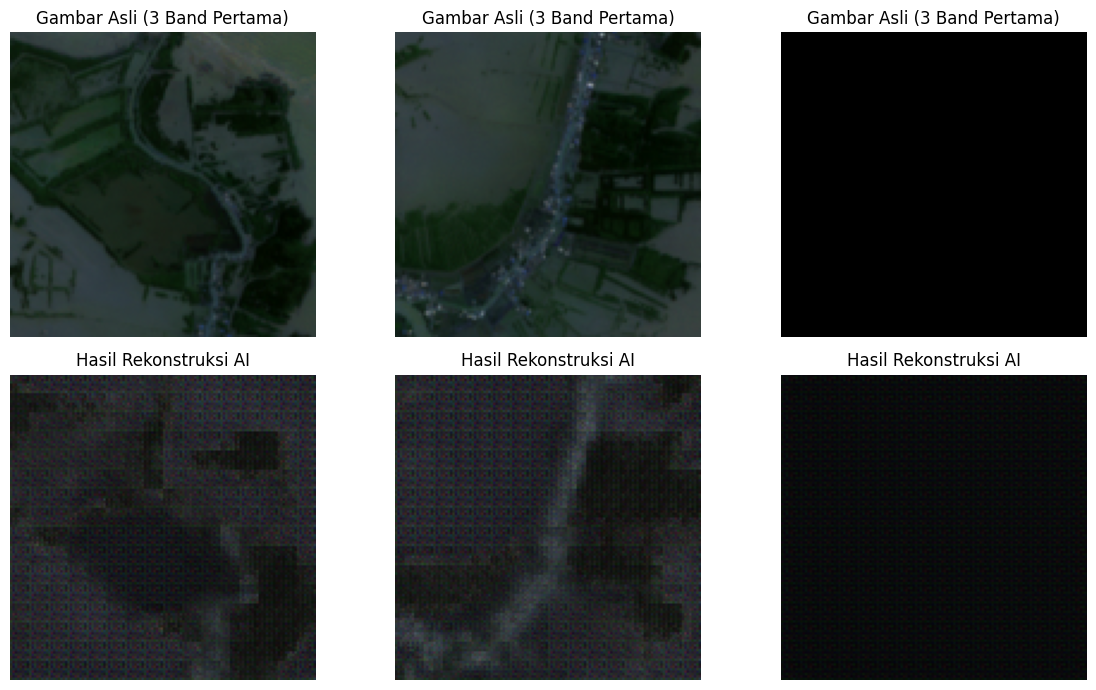

In [20]:
model.eval()
with torch.no_grad():
    inputs, _ = next(iter(val_loader))
    inputs = inputs.to(DEVICE)
    outputs = model(inputs)

# Kembalikan dimensi dari (B, C, H, W) ke (B, H, W, C) untuk plotting
inputs = inputs.cpu().numpy().transpose(0, 2, 3, 1)
outputs = outputs.cpu().numpy().transpose(0, 2, 3, 1)

# Plot 3 sampel perbandingan (Hanya mengambil 3 channel pertama [:, :, :3] untuk visualisasi)
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for i in range(3):
    # [:, :, :3] memastikan Matplotlib tidak error membaca 6 channel
    axes[0, i].imshow(inputs[i][:, :, :3])
    axes[0, i].set_title("Gambar Asli (3 Band Pertama)")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(outputs[i][:, :, :3])
    axes[1, i].set_title("Hasil Rekonstruksi AI")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()